<a href="https://www.kaggle.com/code/atrbyg24/student-performance-factors?scriptVersionId=224875797" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This project analyzes factors affecting student performance using a dataset which contains information on study habits, attendance, and exam scores. The goal is to identify key factors influencing students' academic success and build models.

Import some packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import FunctionTransformer,OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer, ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

Let's load the dataset.

In [2]:
student_data = pd.read_csv('/kaggle/input/student-performance-factors/StudentPerformanceFactors.csv')

Let's examine the first few entries of the data.

In [3]:
student_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Note that the columns 'Teacher_Quality', 'Parental_Education_Level' and 'Distance_from_Home' contain missing entries which we will have to deal with later. The dataset contains a mix of numerical and categorical columns.

In [5]:
student_data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


One thing that jumps out is that the highest exam score is 101. One would generally assume that exam scores range between 0 and 100. It is possible there was extra credit on this exam, but there is no additional information given in the original dataset. Seeing that the maximum score for 'Previous_Scores' is 100, we might want to treat exam scores above 100 as outliers and remove them from the dataset.

In [6]:
student_data[student_data['Exam_Score'] > 100.0]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


Since there is only one student that scored above 100, let us remove this datapoint.

In [7]:
student_data.drop(index=1525,axis=0,inplace=True)

From our previous models, we found that some features are not important predictors of 'Exam_Score'. Let us drop them. 

In [8]:
student_data.drop(columns=['Internet_Access','Gender','Learning_Disabilities'],inplace=True)

Before we perform any further analysis, let us split the dataset into a train and test set.

In [9]:
train_set, test_set = train_test_split(student_data,test_size = 0.2,random_state=42)

Let's first tackle the missing values.

In [10]:
train_set['Teacher_Quality'].value_counts()

Teacher_Quality
Medium    3128
High      1562
Low        532
Name: count, dtype: int64

In [11]:
train_set['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     2606
College         1584
Postgraduate    1029
Name: count, dtype: int64

In [12]:
train_set['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3095
Moderate    1610
Far          527
Name: count, dtype: int64

Based on the data, we can just fill in the missing datapoints with the most frequent values.

In [13]:
student_train = train_set.copy()

In [14]:
numeric_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions',
                'Physical_Activity','Exam_Score']
cat_cols = ['Parental_involvement','Access_to_Resources','Motivation_Level',
            'Family_Income','Teacher_Quality','School_Type','Peer_influence',
            'Parental_Education_Level','Distance_from_Home']

In [15]:
corr_matrix = student_train[numeric_cols].corr()

In [16]:
corr_matrix['Exam_Score'].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.577834
Hours_Studied        0.434553
Previous_Scores      0.167956
Tutoring_Sessions    0.155468
Physical_Activity    0.029748
Sleep_Hours         -0.017977
Name: Exam_Score, dtype: float64

'Attendance' and 'Hours_Studied' seem to be the most correlated features with 'Exam_Score' which makes sense. 

In [17]:
student_train['Study_Sleep_Ratio'] = student_train['Hours_Studied']/student_train['Sleep_Hours']
student_train['Physical_Sleep_Ratio'] = student_train['Physical_Activity']/student_train['Sleep_Hours']
numeric_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions',
                'Physical_Activity','Exam_Score','Study_Sleep_Ratio','Physical_Sleep_Ratio']

In [18]:
corr_matrix = student_train[numeric_cols].corr()
corr_matrix['Exam_Score'].sort_values(ascending=False)

Exam_Score              1.000000
Attendance              0.577834
Hours_Studied           0.434553
Study_Sleep_Ratio       0.350868
Previous_Scores         0.167956
Tutoring_Sessions       0.155468
Physical_Sleep_Ratio    0.038486
Physical_Activity       0.029748
Sleep_Hours            -0.017977
Name: Exam_Score, dtype: float64

Let's examine the distributions of the numerical features.

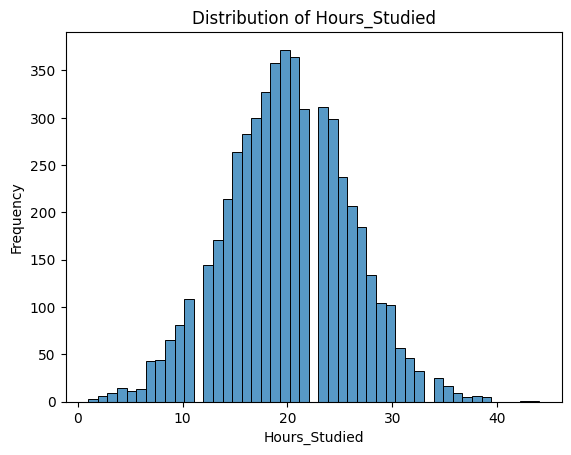

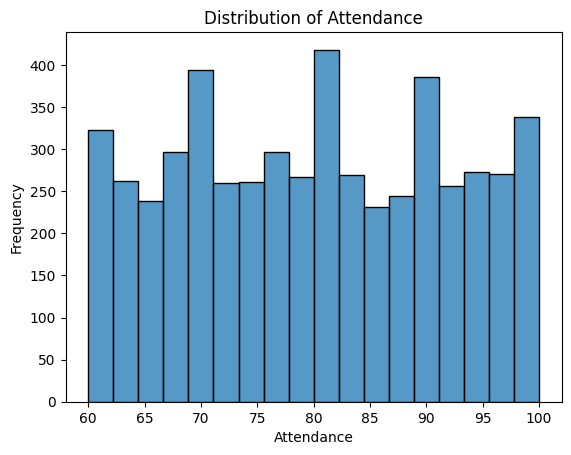

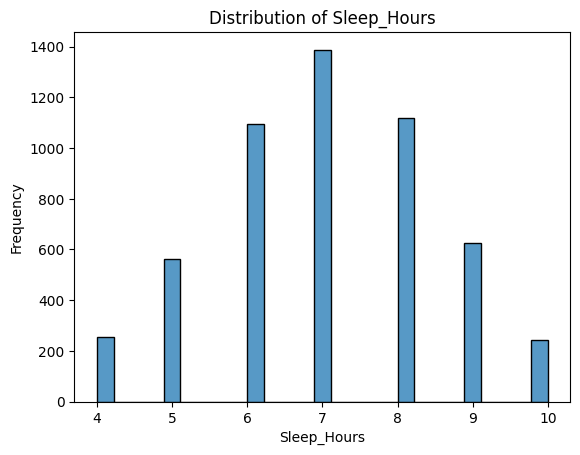

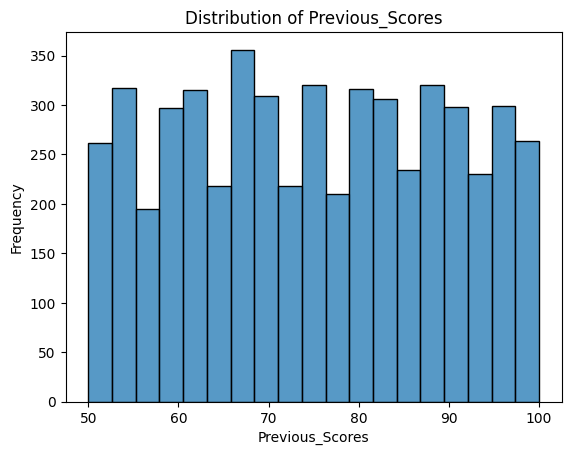

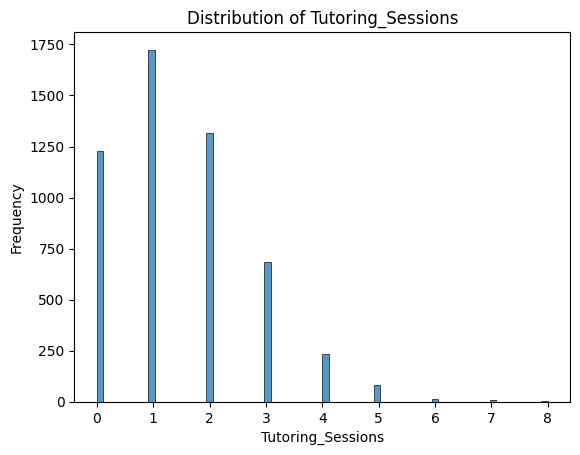

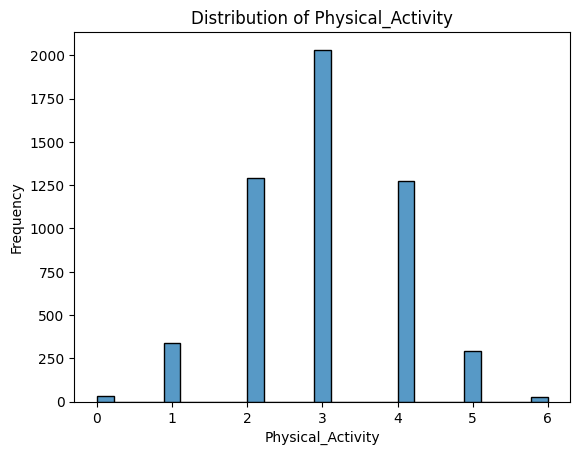

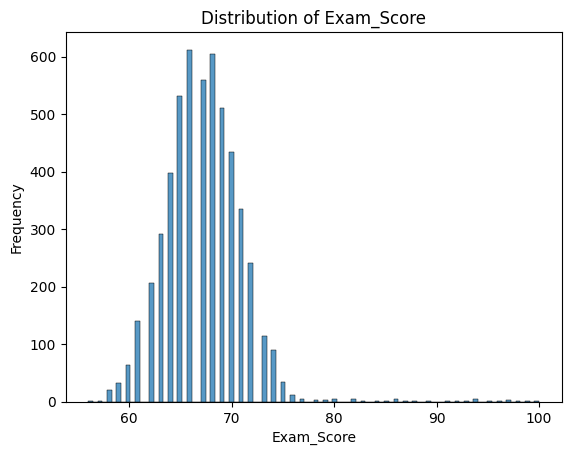

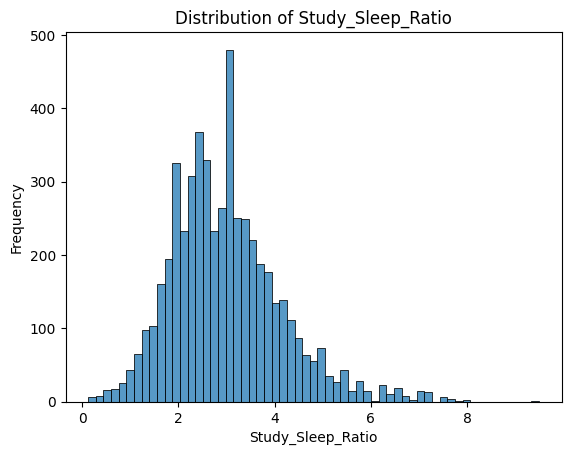

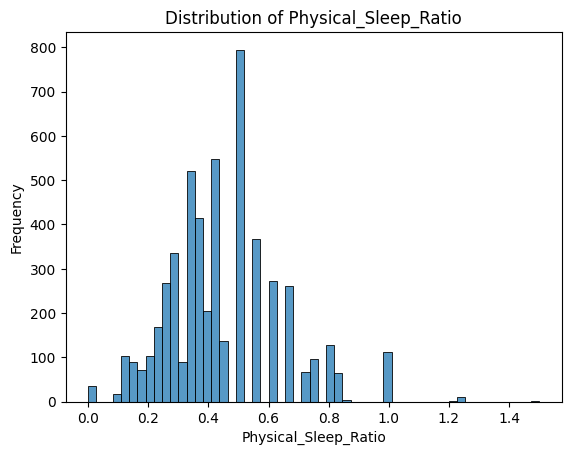

In [19]:
for num_col in numeric_cols:
    plt.figure()  
    sns.histplot(data=student_train, x=num_col)
    plt.title(f"Distribution of {num_col}") 
    plt.xlabel(num_col) 
    plt.ylabel("Frequency") 
    plt.show() 
    plt.close()

Most of the features look to be close to normally distributed or uniformly distributed besides 'Tutoring_Sessions', 'Exam_Score' and the new ratio features. We can transform these by taking the log so they are closer to a normal distribution. This could improve the model performance later on.

In [20]:
student_train['log_tutor'] = np.log1p(student_train['Tutoring_Sessions'])
student_train['log_exams'] = np.log1p(student_train['Exam_Score'])

<Axes: xlabel='log_tutor', ylabel='Count'>

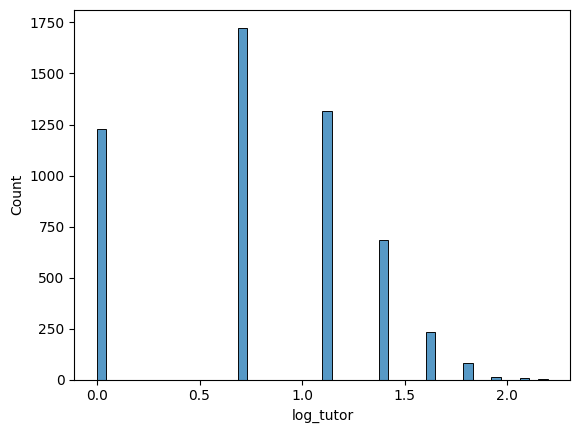

In [21]:
sns.histplot(data=student_train,x='log_tutor')

<Axes: xlabel='log_exams', ylabel='Count'>

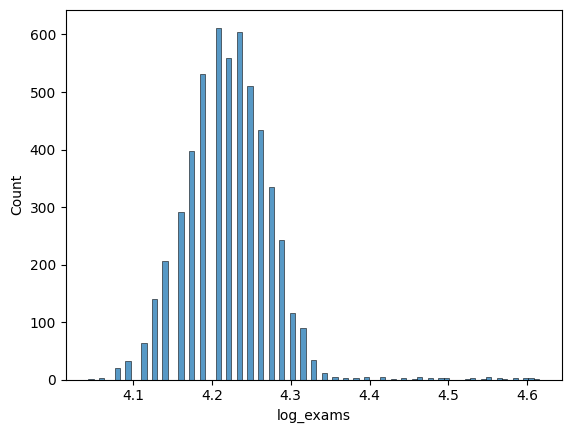

In [22]:
sns.histplot(data=student_train,x='log_exams')

Now let's examine the categorical columns.

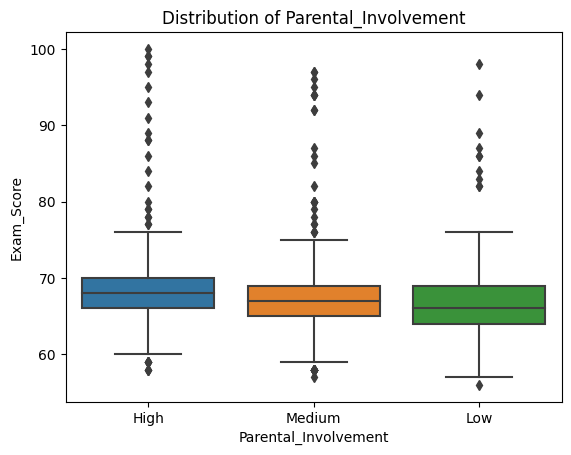

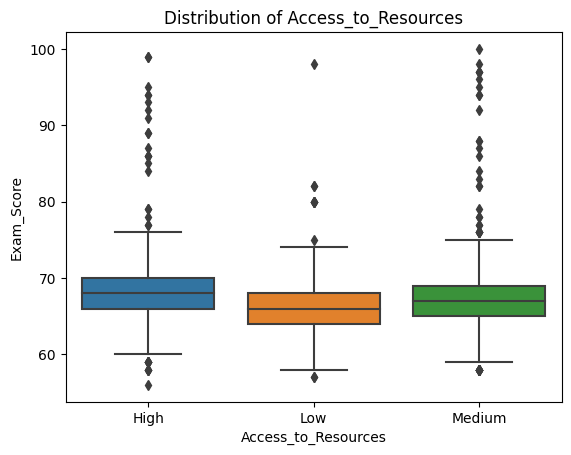

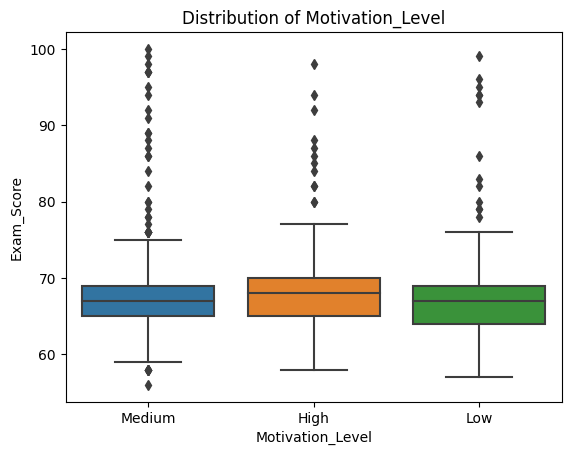

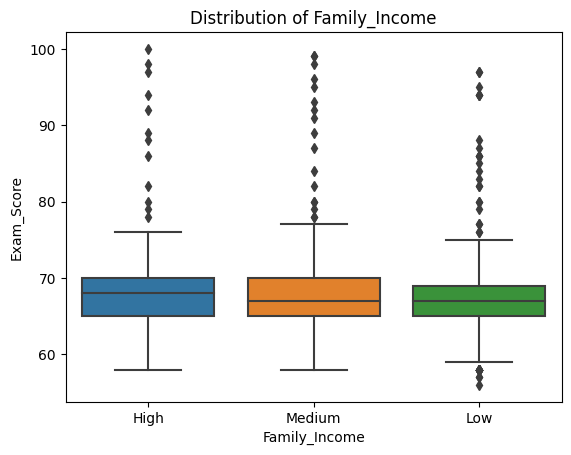

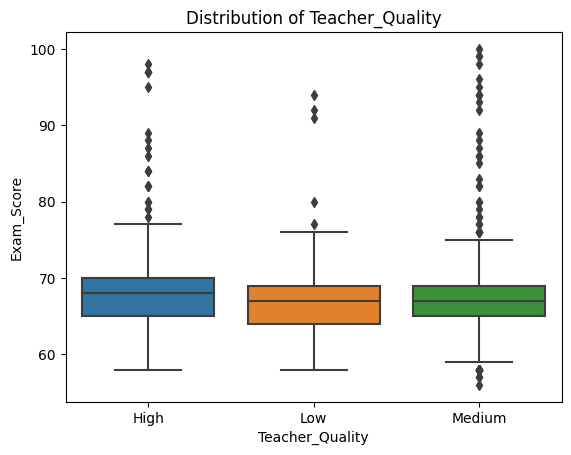

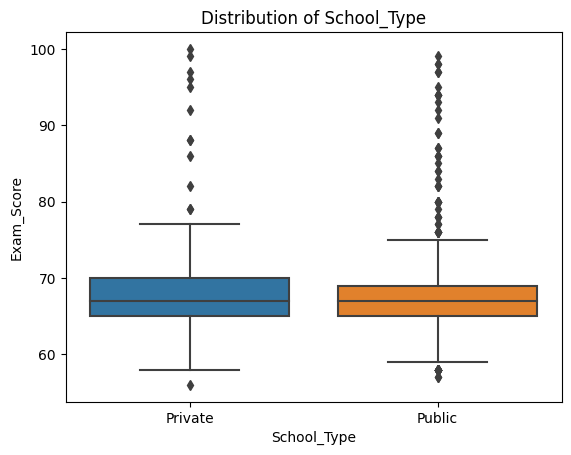

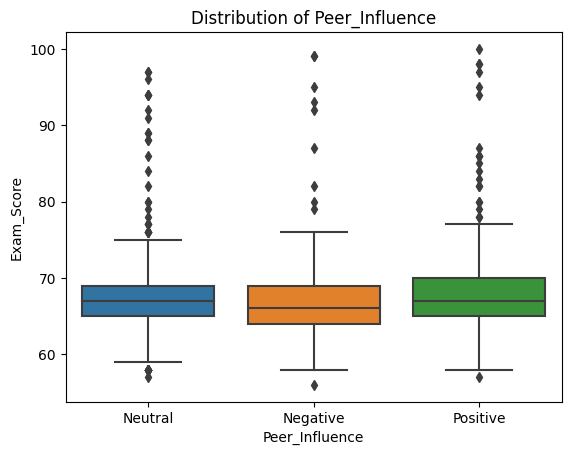

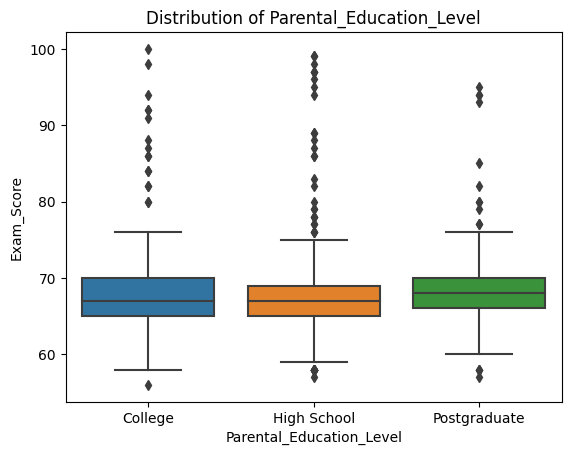

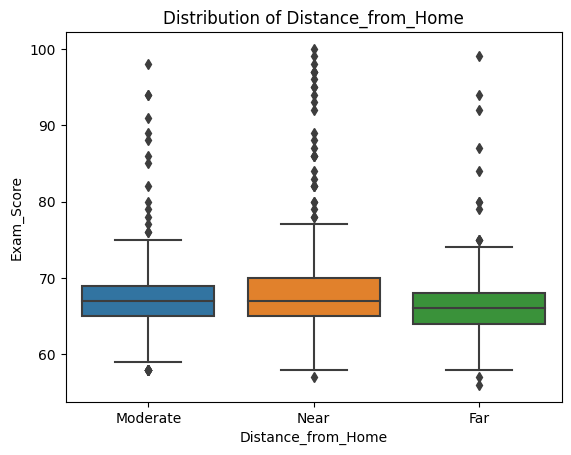

In [23]:
cat_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level',
            'Family_Income','Teacher_Quality','School_Type','Peer_Influence',
            'Parental_Education_Level','Distance_from_Home']

for cat_col in cat_cols:
    plt.figure()  
    sns.boxplot(x=cat_col, y='Exam_Score', data=student_train)
    plt.title(f"Distribution of {cat_col}") 
    plt.xlabel(cat_col) 
    plt.ylabel("Exam_Score") 
    plt.show() 
    plt.close()

The distributions seem quite similar though that could be misleading due to the difference in sample sizes of each feature. In any case, if we find that these features are unimportant to our models. We can consider dropping them.

In [24]:
for cat_col in cat_cols:
    print(student_train[cat_col].value_counts())

Parental_Involvement
Medium    2704
High      1515
Low       1065
Name: count, dtype: int64
Access_to_Resources
Medium    2672
High      1587
Low       1025
Name: count, dtype: int64
Motivation_Level
Medium    2685
Low       1547
High      1052
Name: count, dtype: int64
Family_Income
Medium    2142
Low       2115
High      1027
Name: count, dtype: int64
Teacher_Quality
Medium    3128
High      1562
Low        532
Name: count, dtype: int64
School_Type
Public     3699
Private    1585
Name: count, dtype: int64
Peer_Influence
Positive    2126
Neutral     2045
Negative    1113
Name: count, dtype: int64
Parental_Education_Level
High School     2606
College         1584
Postgraduate    1029
Name: count, dtype: int64
Distance_from_Home
Near        3095
Moderate    1610
Far          527
Name: count, dtype: int64


Let's start building some models.

In [25]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

ratio_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                         FunctionTransformer(column_ratio,feature_names_out=ratio_name),StandardScaler())

log_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                            FunctionTransformer(np.log1p,feature_names_out="one-to-one"),
                            StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),OneHotEncoder(handle_unknown="ignore"))

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                    StandardScaler())

In [26]:
preprocessing = ColumnTransformer([
    ("study_sleep",ratio_pipeline,["Hours_Studied","Sleep_Hours"]),
    ("physical_sleep",ratio_pipeline,["Physical_Activity","Sleep_Hours"]),
    ("log",log_pipeline,["Tutoring_Sessions"]),
    ("cat",cat_pipeline,make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline)

In [27]:
X_train = train_set.drop("Exam_Score",axis=1)
y_train = train_set["Exam_Score"]
X_test = test_set.drop("Exam_Score",axis=1)
y_test = test_set["Exam_Score"]

Let's start with linear regression.

In [28]:
lin_reg = make_pipeline(preprocessing,LinearRegression())
lin_reg.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('study_sleep',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Tutoring_Sessions']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78f8f0c71f00>)])),
                ('linearregression', LinearRegression())])

In [29]:
lin_predicts = lin_reg.predict(X_train)

In [30]:
lin_rmse = mean_squared_error(y_train,np.clip(lin_predicts,0,100),squared=False)
lin_rmse

2.402306901060773

Now let's try a decision tree.

In [31]:
tree_reg = make_pipeline(preprocessing,DecisionTreeRegressor(random_state=42))
tree_reg.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('study_sleep',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x...
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Tutoring_Sessions']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x78f8f0c71f00>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [32]:
tree_predicts = tree_reg.predict(X_train)
tree_rmse = mean_squared_error(y_train,tree_predicts,squared=False)
tree_rmse

0.0

Looks like we are overfitting a lot. Let's use Cross-Validation to evaluate this model.

In [33]:
tree_rmses = -cross_val_score(tree_reg,X_train,y_train,scoring="neg_root_mean_squared_error",cv=10)
pd.Series(tree_rmses).describe()

count    10.000000
mean      3.760146
std       0.446013
min       3.226485
25%       3.355966
50%       3.751376
75%       4.068989
max       4.507149
dtype: float64

Based on the mean, the decision tree seems to perform worse than linear regression. Now let's try a random forest.

In [34]:
forest_reg = make_pipeline(preprocessing,RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg,X_train,y_train,scoring="neg_root_mean_squared_error",cv=10)
pd.Series(forest_rmses).describe()

count    10.000000
mean      2.571747
std       0.483283
min       1.626051
25%       2.366867
50%       2.587531
75%       2.876422
max       3.310520
dtype: float64

This still performs slightly worse than linear regression but maybe we can improve it by fine-tuning. 

In [35]:
full_pipeline = Pipeline([
    ("preprocessing",preprocessing),
    ("random_forest",RandomForestRegressor(random_state=42)),
])

param_distribs = {'random_forest__max_features':randint(low=2,high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline,param_distributions=param_distribs,n_iter=10,cv=3,
    scoring='neg_root_mean_squared_error',random_state=42)
rnd_search.fit(X_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('study_sleep',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_nam...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               <sklearn.compose._column_transformer.make_column_selector object at 0x78f8f0c71f00>)])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78f8efb4abf0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [36]:
final_model = rnd_search.best_estimator_

In [37]:
feature_importances = final_model["random_forest"].feature_importances_

In [38]:
sorted(zip(feature_importances,final_model["preprocessing"].get_feature_names_out()),reverse=True)

[(0.3654398402165798, 'remainder__Attendance'),
 (0.1942702463938633, 'study_sleep__ratio'),
 (0.08329206439594858, 'remainder__Previous_Scores'),
 (0.05150383265439662, 'physical_sleep__ratio'),
 (0.03397944319692429, 'log__Tutoring_Sessions'),
 (0.019318232122940947, 'cat__Access_to_Resources_High'),
 (0.018788541765417766, 'cat__Parental_Involvement_High'),
 (0.013805124998326854, 'cat__Access_to_Resources_Low'),
 (0.012100537389819654, 'cat__Parental_Involvement_Low'),
 (0.010941188505980892, 'cat__Teacher_Quality_High'),
 (0.010354259493994327, 'cat__Parental_Education_Level_High School'),
 (0.010224225823447383, 'cat__Peer_Influence_Negative'),
 (0.009953947940280905, 'cat__Peer_Influence_Positive'),
 (0.009891442426178523, 'cat__Motivation_Level_Low'),
 (0.009553724138460984, 'cat__Motivation_Level_High'),
 (0.009536053168060787, 'cat__Family_Income_Low'),
 (0.00953138131251189, 'cat__Parental_Education_Level_Postgraduate'),
 (0.009513506507238468, 'cat__Family_Income_High'),
 (

This gave us some important information. 'Attendance' seems to be the most important factor for 'Exam_Score'. Some features such as 'School_Type' and 'Internet_Access' do not seem to matter as much. We can consider dropping them.

In [39]:
final_predictions = final_model.predict(X_test)

In [40]:
final_rmse = mean_squared_error(y_test,final_predictions,squared=False)
final_rmse

2.097130793321323

Let's compare this to the first linear regression model.

In [41]:
lin_test_predicts = lin_reg.predict(X_test)
lin_test_rmse = mean_squared_error(y_test,lin_test_predicts,squared=False)
lin_test_rmse

1.9346942055544298

This simpler model where we dropped some features ended up performing worse than using the entire dataset.